# Gold Speaker Timeline (Gantt)

Visualize speaker distribution over time for gold talks.

- One row per talk (`sample_id`)
- Different color per speaker
- Built from `dataset.pickle` (with fallback to `transcripts/transcribed/*.json` when needed)

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "analysis" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config.settings import get_settings  # noqa: E402

# Reload to ensure we pick up local changes while iterating in notebooks.
import importlib  # noqa: E402
import analysis.speaker_timeline as speaker_timeline  # noqa: E402
importlib.reload(speaker_timeline)  # noqa: E402

from analysis.speaker_timeline import (  # noqa: E402
    build_speaker_share_df,
    load_gold_speaker_timeline,
    plot_speaker_timeline_gantt,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

In [2]:
settings = get_settings()

DATASET_PICKLE_PATH = os.getenv("DATASET_PICKLE_PATH", settings.dataset_pickle_path)
TRANSCRIPTS_DIR = os.getenv("TRANSCRIPTS_DIR", settings.transcripts_dir)
MAX_SAMPLES = int(os.getenv("MAX_SAMPLES", "25"))

# Optional comma-separated filter: "D0420-S1-T01,D0420-S2-T02"
SAMPLE_IDS_RAW = os.getenv("SAMPLE_IDS", "").strip()
SAMPLE_IDS = [x.strip() for x in SAMPLE_IDS_RAW.split(",") if x.strip()] if SAMPLE_IDS_RAW else None

print("dataset:", DATASET_PICKLE_PATH)
print("transcripts_dir:", TRANSCRIPTS_DIR)
print("max_samples:", MAX_SAMPLES)
print("sample_ids:", SAMPLE_IDS)

dataset: ./data/raw/dataset.pickle
transcripts_dir: ./data/raw/transcripts
max_samples: 25
sample_ids: None


In [3]:
timeline_df = load_gold_speaker_timeline(
    dataset_pickle_path=DATASET_PICKLE_PATH,
    transcripts_dir=TRANSCRIPTS_DIR,
    sample_ids=SAMPLE_IDS,
    limit=MAX_SAMPLES,
)

share_df = build_speaker_share_df(timeline_df)

print("rows:", len(timeline_df))
print("samples:", timeline_df['sample_id'].nunique() if not timeline_df.empty else 0)
print("speakers:", sorted(timeline_df['speaker'].dropna().unique()) if not timeline_df.empty else [])
display(timeline_df.head(20))

rows: 2537
samples: 25
speakers: ['1', '2']


,sample_id,speaker,start_s,end_s,duration_s,source
0,D0420-S1-T01,1,0.000000,0.003077,0.003077,transcribed_json_relative
1,D0420-S1-T01,2,0.003077,0.008846,0.005769,transcribed_json_relative
2,D0420-S1-T01,1,0.008846,0.009615,0.000769,transcribed_json_relative
3,D0420-S1-T01,2,0.009615,0.015000,0.005385,transcribed_json_relative
4,D0420-S1-T01,1,0.015000,0.018462,0.003462,transcribed_json_relative
5,D0420-S1-T01,2,0.018462,0.041923,0.023462,transcribed_json_relative
6,D0420-S1-T01,1,0.041923,0.048077,0.006154,transcribed_json_relative
7,D0420-S1-T01,2,0.048077,0.052308,0.004231,transcribed_json_relative
8,D0420-S1-T01,1,0.052308,0.056154,0.003846,transcribed_json_relative
9,D0420-S1-T01,2,0.056154,0.070385,0.014231,transcribed_json_relative


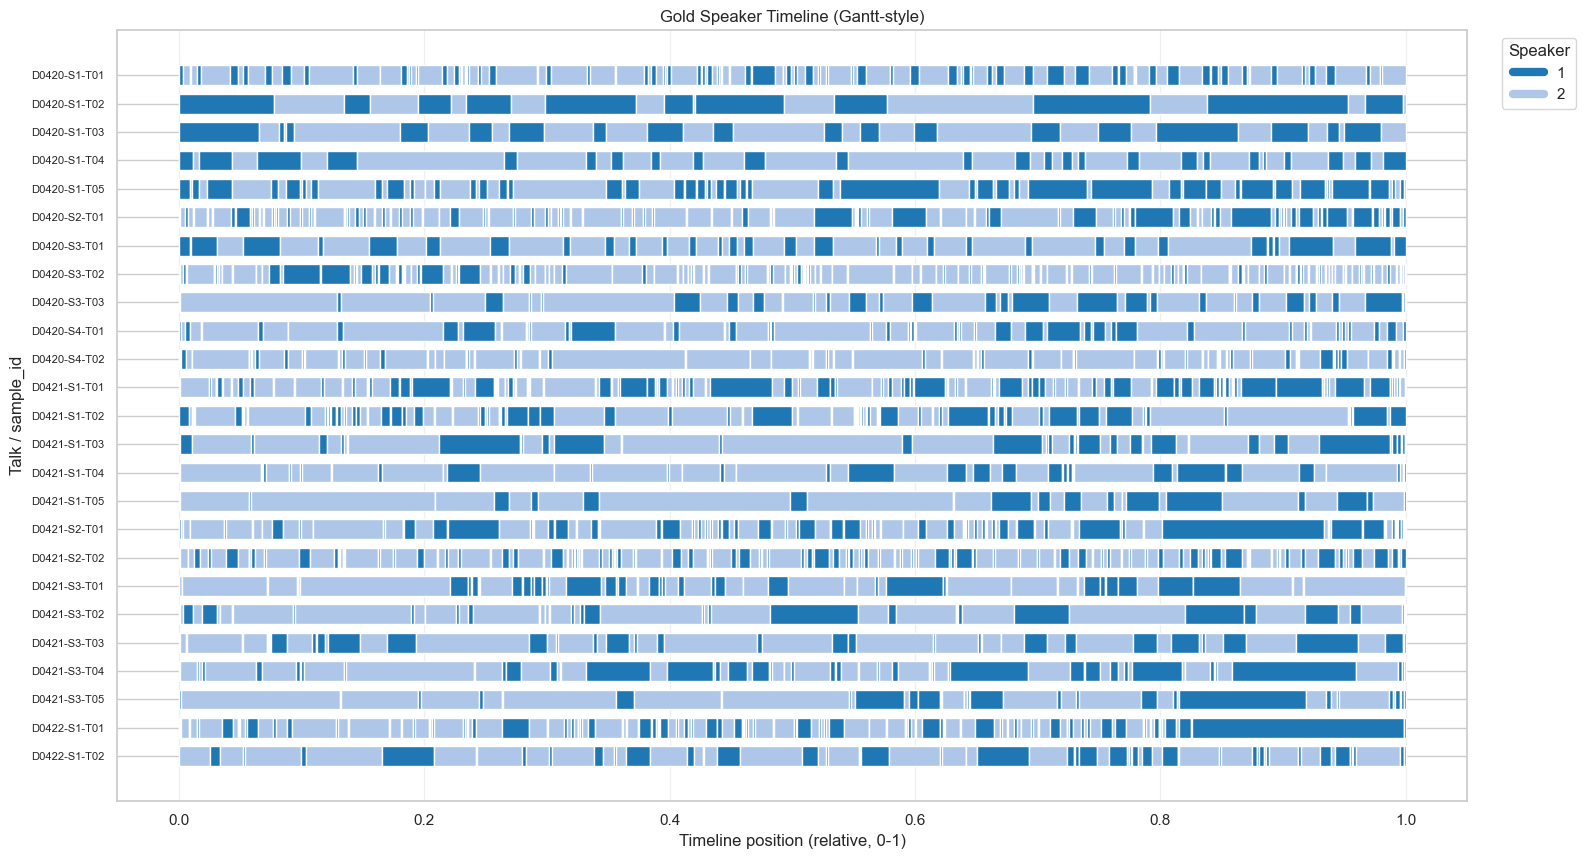

In [4]:
fig, ax = plot_speaker_timeline_gantt(
    timeline_df,
    max_samples=MAX_SAMPLES,
    figsize=(16, max(6, min(16, 0.35 * max(1, timeline_df['sample_id'].nunique() if not timeline_df.empty else 1)))),
)
plt.show()

,sample_id,speaker,speaker_duration_s,sample_duration_s,speaker_share
0,D0420-S1-T01,1,0.290385,1.0,0.290385
1,D0420-S1-T01,2,0.709615,1.0,0.709615
2,D0420-S1-T02,1,0.617934,1.0,0.617934
3,D0420-S1-T02,2,0.382066,1.0,0.382066
4,D0420-S1-T03,1,0.439785,1.0,0.439785
5,D0420-S1-T03,2,0.560215,1.0,0.560215
6,D0420-S1-T04,1,0.299870,1.0,0.299870
7,D0420-S1-T04,2,0.700130,1.0,0.700130
8,D0420-S1-T05,1,0.570568,1.0,0.570568
9,D0420-S1-T05,2,0.429432,1.0,0.429432


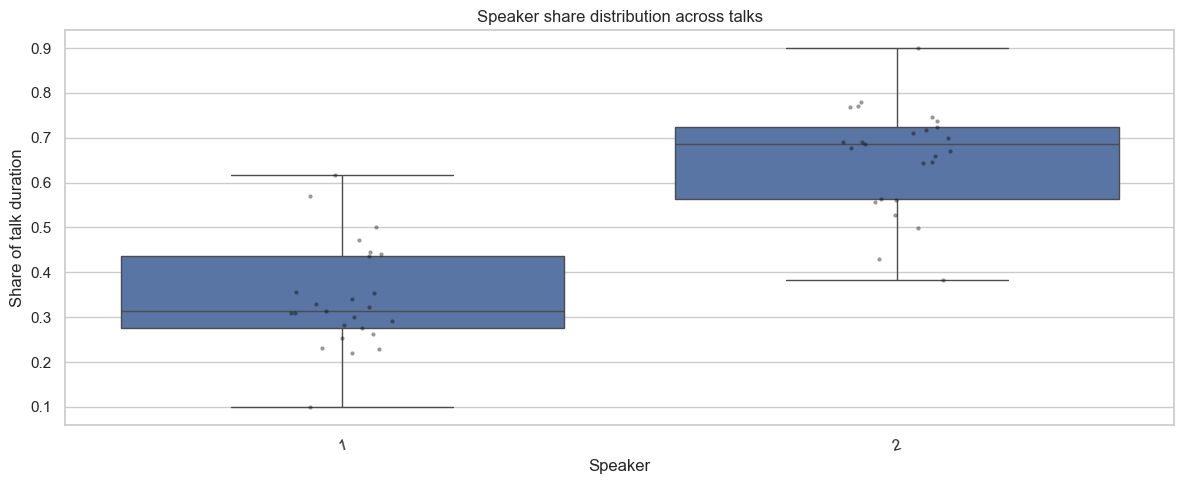

In [5]:
if not share_df.empty:
    display(share_df.sort_values(["sample_id", "speaker"]).head(40))

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=share_df, x="speaker", y="speaker_share")
    sns.stripplot(data=share_df, x="speaker", y="speaker_share", color="black", alpha=0.4, size=3)
    plt.title("Speaker share distribution across talks")
    plt.xlabel("Speaker")
    plt.ylabel("Share of talk duration")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

,sample_id,total_duration_s,turn_count
7,D0420-S3-T02,1.0,261
17,D0421-S2-T02,1.0,191
11,D0421-S1-T01,1.0,183
5,D0420-S2-T01,1.0,174
23,D0422-S1-T01,1.0,165
16,D0421-S2-T01,1.0,150
0,D0420-S1-T01,1.0,144
10,D0420-S4-T02,1.0,140
12,D0421-S1-T02,1.0,131
4,D0420-S1-T05,1.0,92


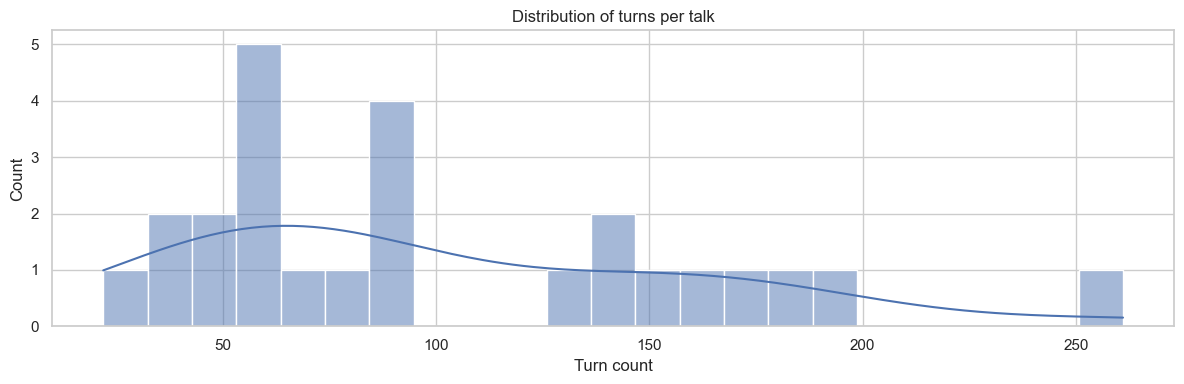

In [6]:
if not timeline_df.empty:
    sample_duration = timeline_df.groupby("sample_id", as_index=False)["duration_s"].sum().rename(columns={"duration_s": "total_duration_s"})
    sample_turns = timeline_df.groupby("sample_id", as_index=False).size().rename(columns={"size": "turn_count"})
    merged = sample_duration.merge(sample_turns, on="sample_id", how="left")

    display(merged.sort_values("turn_count", ascending=False).head(20))

    # If we have true timestamps, show duration distribution; otherwise show turn-count distribution.
    has_absolute_time = bool((timeline_df["source"] == "dataset.pickle").any() or (timeline_df["source"] == "transcribed_json").any())

    plt.figure(figsize=(12, 4))
    if has_absolute_time:
        vals = merged["total_duration_s"].dropna()
        if vals.empty:
            plt.text(0.5, 0.5, "No duration data", ha="center", va="center")
            plt.axis("off")
        else:
            n = int(min(30, max(5, vals.nunique())))
            sns.histplot(vals, bins=n, kde=True)
            plt.title("Distribution of talk durations")
            plt.xlabel("Duration (seconds)")
    else:
        # Relative timeline mode: duration is normalized, so turns-per-talk is more informative.
        vals = merged["turn_count"].dropna()
        if vals.empty:
            plt.text(0.5, 0.5, "No turn-count data", ha="center", va="center")
            plt.axis("off")
        else:
            n = int(min(30, max(5, vals.nunique())))
            sns.histplot(vals, bins=n, kde=True)
            plt.title("Distribution of turns per talk")
            plt.xlabel("Turn count")

    plt.tight_layout()
    plt.show()